In [2]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, Dataset
import kagglehub

# 1. Класс для работы с MNIST в формате CSV
class MNISTCSV(Dataset):
    def __init__(self, file_path):
        df = pd.read_csv(file_path)
        self.labels = df.iloc[:, 0].values
        self.images = df.iloc[:, 1:].values.astype(np.float32) / 255.0
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.images[idx]), torch.tensor(self.labels[idx], dtype=torch.long)

In [7]:
# 2. Реализация слоев для сжатия и оптимизации

class LowRankLinear(nn.Module):
    def __init__(self, in_f, out_f, rank):
        super().__init__()
        self.main = nn.Sequential(nn.Linear(in_f, rank, bias=False), nn.Linear(rank, out_f))
    def forward(self, x): return self.main(x)

class SimpleTTLinear(nn.Module):
    def __init__(self, in_f, out_f, rank):
        super().__init__()
        # Разделяем вход на две части и обрабатываем каждую
        self.rank = rank
        self.core1 = nn.Parameter(torch.randn(in_f // 2, rank) * 0.01)
        self.core2 = nn.Parameter(torch.randn(in_f // 2, rank) * 0.01)
        self.output_layer = nn.Linear(rank, out_f)

    def forward(self, x):
        # Используем обе половины входных данных
        mid = x.shape[1] // 2
        h1 = torch.matmul(x[:, :mid], self.core1)
        h2 = torch.matmul(x[:, mid:], self.core2)
        # Суммируем вклады и пропускаем через выходной слой
        return self.output_layer(h1 + h2)

class MonarchLinear(nn.Module):
    def __init__(self, dim, n_blocks):
        super().__init__()
        self.n_blocks = n_blocks
        self.block_size = dim // n_blocks
        self.w1 = nn.Parameter(torch.randn(n_blocks, self.block_size, self.block_size) * 0.01)
        self.w2 = nn.Parameter(torch.randn(n_blocks, self.block_size, self.block_size) * 0.01)
        self.bias = nn.Parameter(torch.zeros(dim))
    def forward(self, x):
        b = x.shape[0]
        x = x.view(b, self.n_blocks, self.block_size)
        x = torch.einsum('bnk,nkj->bnj', x, self.w1)
        x = x.transpose(1, 2).contiguous()
        x = torch.einsum('bnk,nkj->bnj', x, self.w2)
        return x.reshape(b, -1) + self.bias

In [12]:
# 3. Утилиты для обучения

def train_and_eval(name, model, train_loader, test_loader, test_dataset, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.002)
    crit = nn.CrossEntropyLoss()
    if 'Pruned' in name:
        for m in model.modules():
            if isinstance(m, nn.Linear): prune.l1_unstructured(m, name='weight', amount=0.5)

    res = {'acc': [], 'params': sum(p.numel() for p in model.parameters())}
    t0 = time.time()
    for e in range(epochs):
        model.train()
        for im, lb in train_loader:
            im, lb = im.to(device), lb.to(device)
            opt.zero_grad(); crit(model(im), lb).backward(); opt.step()
        model.eval(); corr = 0
        with torch.no_grad():
            for im, lb in test_loader:
                im, lb = im.to(device), lb.to(device)
                corr += (model(im).argmax(1) == lb).sum().item()
        acc = corr / len(test_dataset)
        res['acc'].append(acc)
        print(f'{name} Ep {e+1}: {acc:.4f}')
    res['time'] = time.time() - t0
    return res

In [16]:
# 4. Запуск экспериментов и сохранение результатов

def run_experiments():
    path = kagglehub.dataset_download('oddrationale/mnist-in-csv')
    train_ds = MNISTCSV(os.path.join(path, 'mnist_train.csv'))
    test_ds = MNISTCSV(os.path.join(path, 'mnist_test.csv'))
    train_ld = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_ld = DataLoader(test_ds, batch_size=1000)

    configs = {
        'Dense': nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10)),
        'Low-Rank': nn.Sequential(LowRankLinear(784, 256, 32), nn.ReLU(), nn.Linear(256, 10)),
        'TT-Approx': nn.Sequential(SimpleTTLinear(784, 256, 64), nn.ReLU(), nn.Linear(256, 10)),
        'Monarch': nn.Sequential(nn.Linear(784, 256), nn.ReLU(), MonarchLinear(256, 16), nn.Linear(256, 10)),
        'Pruned': nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
    }

    results = {}
    for name, model in configs.items():
        print(f'--- {name} ---')
        try: results[name] = train_and_eval(name, model, train_ld, test_ld, test_ds)
        except Exception as e: print(f'Error {name}: {e}')
    return results

results = run_experiments()

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
--- Dense ---
Dense Ep 1: 0.9574
Dense Ep 2: 0.9742
Dense Ep 3: 0.9758
Dense Ep 4: 0.9790
Dense Ep 5: 0.9781
--- Low-Rank ---
Low-Rank Ep 1: 0.9543
Low-Rank Ep 2: 0.9630
Low-Rank Ep 3: 0.9650
Low-Rank Ep 4: 0.9701
Low-Rank Ep 5: 0.9721
--- TT-Approx ---
TT-Approx Ep 1: 0.9531
TT-Approx Ep 2: 0.9640
TT-Approx Ep 3: 0.9651
TT-Approx Ep 4: 0.9639
TT-Approx Ep 5: 0.9712
--- Monarch ---
Monarch Ep 1: 0.9524
Monarch Ep 2: 0.9708
Monarch Ep 3: 0.9730
Monarch Ep 4: 0.9713
Monarch Ep 5: 0.9771
--- Pruned ---
Pruned Ep 1: 0.9581
Pruned Ep 2: 0.9692
Pruned Ep 3: 0.9731
Pruned Ep 4: 0.9770
Pruned Ep 5: 0.9764


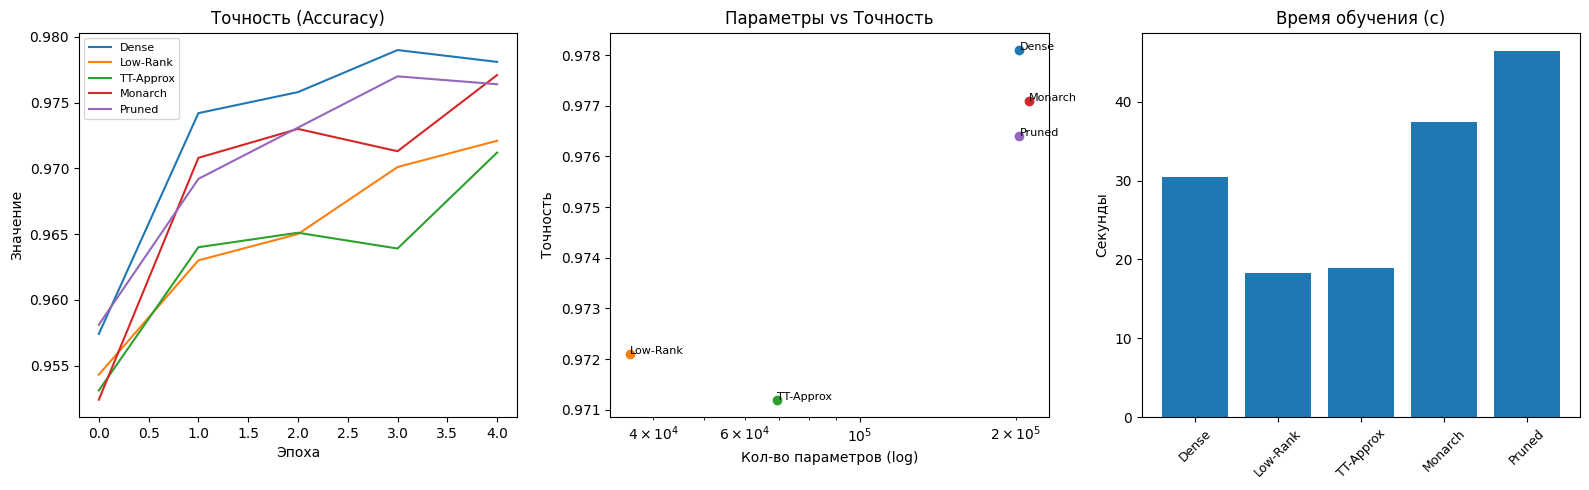

In [17]:
# 5. Визуализация результатов

def plot_results(results):
    if not results:
        print("Нет данных для отображения.")
        return

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    # 1. Точность
    for n, r in results.items(): ax[0].plot(r['acc'], label=n)
    ax[0].set_title('Точность (Accuracy)')
    ax[0].set_xlabel('Эпоха')
    ax[0].set_ylabel('Значение')
    ax[0].legend(prop={'size': 8}, loc='best')

    # 2. Параметры vs Точность
    for n, r in results.items():
        ax[1].scatter(r['params'], r['acc'][-1])
        ax[1].annotate(n, (r['params'], r['acc'][-1]), fontsize=8)
    ax[1].set_xscale('log')
    ax[1].set_title('Параметры vs Точность')
    ax[1].set_xlabel('Кол-во параметров (log)')
    ax[1].set_ylabel('Точность')

    # 3. Время обучения
    ax[2].bar(results.keys(), [r['time'] for r in results.values()])
    ax[2].set_title('Время обучения (с)')
    ax[2].set_ylabel('Секунды')
    ax[2].tick_params(axis='x', rotation=45, labelsize=9)

    plt.tight_layout()
    plt.show()

plot_results(results)